In [29]:
# %%
import sys
sys.path.insert(0, '..')
import helper_functions
from constants import *

import eelbrain
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

In [30]:
# %%
SUBJECTS = helper_functions.get_subjects()

checks = [
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD, False),
    (PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD, False),
    (PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD, False),
    (PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD, False),
]

# Latencies (seconds) per model
latencies = {
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD): [-0.190],
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD): [-0.140, -0.08],
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD): [-0.35, -0.080],
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD): [-0.095],
}

colors = {
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD): 'tab:blue',
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, MODEL_TYPE.BACKWARD): 'tab:orange',
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD): 'tab:green',
    helper_functions.get_trf_model_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.IGNORED,  MODEL_TYPE.BACKWARD): 'tab:red',
}

In [ ]:
# %%
trf_data, n_subjects = helper_functions.load_trfs(checks, trf_dir=MAT_FILE_TRF_DIR)

# Compute grand mean TRFs
backward_trfs = {}
for predictor, attention, model, padded in checks:
    model_name = helper_functions.get_trf_model_name(predictor, attention, model, padded)
    trf_list   = [trf.h_scaled[0] if isinstance(trf.h_scaled, tuple) else trf.h_scaled 
                  for trf in trf_data[model_name]]
    backward_trfs[model_name] = eelbrain.combine(trf_list).mean('case')
    print(f"  ✓ Grand mean computed ({len(trf_list)} subjects)")

  ✓ S1
  ✓ S2
  ✓ S3
  ✓ S4
  ✓ S5
  ✓ S6
  ✓ S7
  ✓ S8
  ✓ S9
  ✓ S10
  ✓ S11
  ✓ S12
  ✓ S13
  ✓ S14
  ✓ S15
  ✓ S16
  ✓ S17
  ✓ S18

Loaded: 18 subjects | Skipped: 0 subjects
  ✓ Grand mean computed (18 subjects)
  ✓ Grand mean computed (18 subjects)
  ✓ Grand mean computed (18 subjects)
  ✓ Grand mean computed (18 subjects)


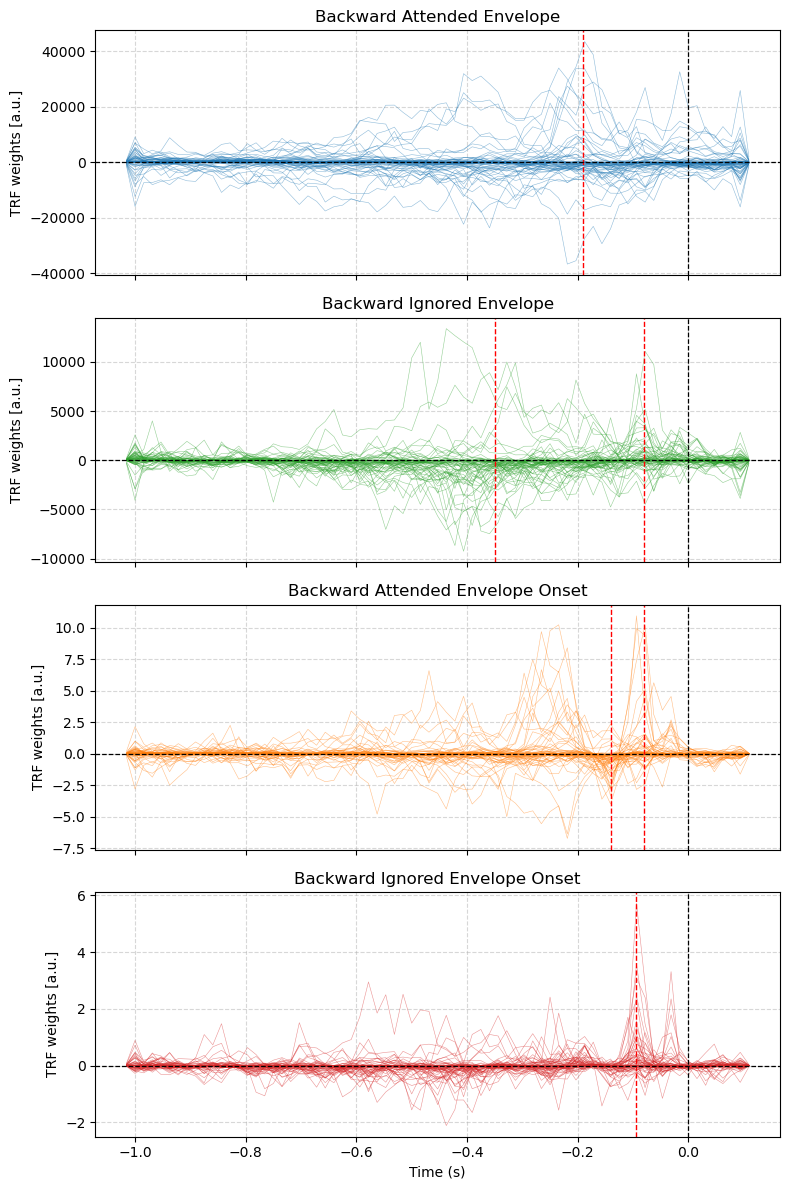

In [32]:
# %%
fig, axes = plt.subplots(len(checks), 1, figsize=(8, 12), sharex=True)

for i, (predictor, attention, model, padded) in enumerate(checks):
    model_name = helper_functions.get_trf_model_name(predictor, attention, model, padded)
    trf        = backward_trfs[model_name]
    trf_plot   = trf.mean('predictor') if 'predictor' in trf.dims else trf

    # trf_plot is sensor x time — plot each sensor as a line
    time_s = np.array(trf_plot.time.times)
    for sensor_idx in range(trf_plot.x.shape[0]):
        axes[i].plot(time_s, trf_plot.x[sensor_idx], 
                     color=colors[model_name], linewidth=0.4, alpha=0.5)

    for t in latencies[model_name]:
        axes[i].axvline(t, color='red', linestyle='--', linewidth=1)

    axes[i].axhline(0, linestyle='--', color='black', linewidth=0.9)
    axes[i].axvline(0, linestyle='--', color='black', linewidth=0.9)
    axes[i].set_title(model_name.replace('_', ' ').title(), fontsize=12)
    axes[i].set_ylabel('TRF weights [a.u.]')
    axes[i].grid(True, linestyle='--', alpha=0.5)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
fig.savefig(FIGURES_DIR / f'{FUGLSANG}-backward-trf.pdf', bbox_inches='tight')
plt.show()